# Clasificación de Asteroides Potencialmente Peligrosos

## Librerias

In [19]:
# Librerias a utilizar.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

#Carga de dataset




In [20]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset Parcial/Asteroid_Dataset.csv')

/tmp/ipython-input-4075938086.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset Parcial/Asteroid_Dataset.csv')


In [21]:
# ---------- Comprobaciones rápidas tras la carga ----------
print("\n--- Resumen rápido ---")
print("pandas:", pd.__version__)
print("shape (filas, columnas):", df.shape)

print("\n--- Primeras 5 filas ---")
display(df.head())

print("\n--- Información de columnas y tipos ---")
print(df.info())

print("\n--- Estadísticos numéricos (describe) ---")
display(df.describe(include='all').T)

# Comprobación y conteo de la columna objetivo 'pha' (si existe)
if 'pha' in df.columns:
    print("\nConteo de clases en 'pha':")
    print(df['pha'].value_counts(dropna=False))
else:
    print("\nNo encontré la columna 'pha'. Columnas disponibles:")
    print(list(df.columns))

# Valores faltantes por columna (las más problemáticas primero)
print("\nValores faltantes por columna (orden descendente):")
print(df.isnull().sum().sort_values(ascending=False).head(30))


--- Resumen rápido ---
pandas: 2.2.2
shape (filas, columnas): (126131, 35)

--- Primeras 5 filas ---


,spkid,full_name,pha,H,diameter,albedo,diameter_sigma,e,a,q,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,2000001,' 1 Ceres',N,3.40,939.4,0.0900,0.2,0.077557,2.767657,2.553006,...,4.613200e-09,6.176900e-08,6.618400e-08,7.355900e-09,1.115900e-11,1.201400e-12,3.686700e-08,9.439100e-09,MBA,0.40633
1,2000002,' 2 Pallas',N,4.20,545.0,0.1010,18.0,0.229972,2.773841,2.135935,...,3.701900e-06,6.412400e-06,9.494400e-06,9.151500e-06,5.054200e-09,4.740800e-10,4.219400e-05,3.749600e-06,MBA,0.36151
2,2000003,' 3 Juno',N,5.33,246.596,0.2140,10.594000000000001,0.256936,2.668285,1.982706,...,3.232100e-06,1.687400e-05,1.795300e-05,8.114300e-06,4.413000e-09,4.463100e-10,3.530500e-05,3.142200e-06,MBA,0.33306
3,2000004,' 4 Vesta',N,3.00,525.4,0.4228,0.2,0.088516,2.362014,2.152938,...,2.207300e-07,3.940500e-07,1.817500e-07,1.335200e-06,1.681800e-09,2.664000e-10,5.480200e-06,1.301000e-06,MBA,0.39592
4,2000005,' 5 Astraea',N,6.90,106.699,0.2740,3.14,0.190913,2.574037,2.082619,...,2.743600e-06,2.926000e-05,3.016900e-05,8.703600e-06,4.902000e-09,5.724700e-10,3.640700e-05,3.618200e-06,MBA,0.51439



--- Información de columnas y tipos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126131 entries, 0 to 126130
Data columns (total 35 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   spkid           126131 non-null  int64  
 1   full_name       126131 non-null  object 
 2   pha             126131 non-null  object 
 3   H               126131 non-null  float64
 4   diameter        126131 non-null  object 
 5   albedo          126131 non-null  float64
 6   diameter_sigma  126131 non-null  object 
 7   e               126131 non-null  float64
 8   a               126131 non-null  float64
 9   q               126131 non-null  float64
 10  i               126131 non-null  float64
 11  om              126131 non-null  float64
 12  w               126131 non-null  float64
 13  ma              126131 non-null  float64
 14  ad              126131 non-null  float64
 15  n               126131 non-null  float64
 16  tp             

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
spkid,126131.0,NaN,NaN,NaN,2153700.355725,131424.268509,2000001.0,2044636.5,2114846.0,2240347.5,2539759.0
full_name,126131,126131,'539759 (2016 UO107)',1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pha,126131,2,N,125975,NaN,NaN,NaN,NaN,NaN,NaN,NaN
H,126131.0,NaN,NaN,NaN,15.048388,1.333276,3.0,14.4,15.2,15.9,22.9
diameter,126131.0,25594.0,3.626,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
albedo,126131.0,NaN,NaN,NaN,0.134927,0.112425,0.001,0.054,0.081,0.2,1.0
diameter_sigma,126131,3043,0.16899999999999998,308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
e,126131.0,NaN,NaN,NaN,0.14356,0.073673,0.000309,0.089394,0.137776,0.189101,0.968396
a,126131.0,NaN,NaN,NaN,2.817265,0.978965,0.62621,2.547302,2.754816,3.094052,281.17471
q,126131.0,NaN,NaN,NaN,2.415783,0.514863,0.08182,2.078295,2.376367,2.695307,40.318708



Conteo de clases en 'pha':
pha
N    125975
Y       156
Name: count, dtype: int64

Valores faltantes por columna (orden descendente):
spkid             0
full_name         0
pha               0
H                 0
diameter          0
albedo            0
diameter_sigma    0
e                 0
a                 0
q                 0
i                 0
om                0
w                 0
ma                0
ad                0
n                 0
tp                0
tp_cal            0
per               0
per_y             0
moid              0
moid_ld           0
sigma_e           0
sigma_a           0
sigma_q           0
sigma_i           0
sigma_om          0
sigma_w           0
sigma_ma          0
sigma_ad          0
dtype: int64


#Exploración del dataset (EDA)

In [22]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

print("\n--- Cantidad de valores únicos por columna ---")
print(df.nunique().sort_values(ascending=False).head(20))


--- Cantidad de valores únicos por columna ---
spkid        126131
full_name    126131
i            126131
n            126131
q            126131
a            126131
e            126131
ad           126131
ma           126131
w            126131
om           126131
per_y        126131
tp           126131
tp_cal       126131
per          126131
moid_ld       89028
moid          89028
sigma_tp      68720
sigma_w       67941
sigma_om      64396
dtype: int64



--- Distribución de la variable 'pha' ---


/tmp/ipython-input-870379580.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pha', data=df, palette='pastel')


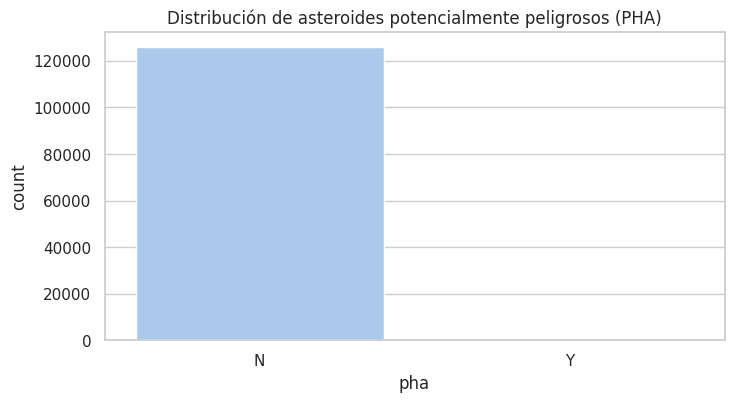

In [18]:
# --- 2. Distribución de la variable objetivo ---
print("\n--- Distribución de la variable 'pha' ---")
sns.countplot(x='pha', data=df, palette='pastel')
plt.title("Distribución de asteroides potencialmente peligrosos (PHA)")
plt.show()

In [23]:
# --- 3. Revisión de columnas numéricas ---
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
print(f"\nTotal de columnas numéricas: {len(numeric_cols)}")
print(numeric_cols.tolist())


Total de columnas numéricas: 30
['spkid', 'H', 'albedo', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms']


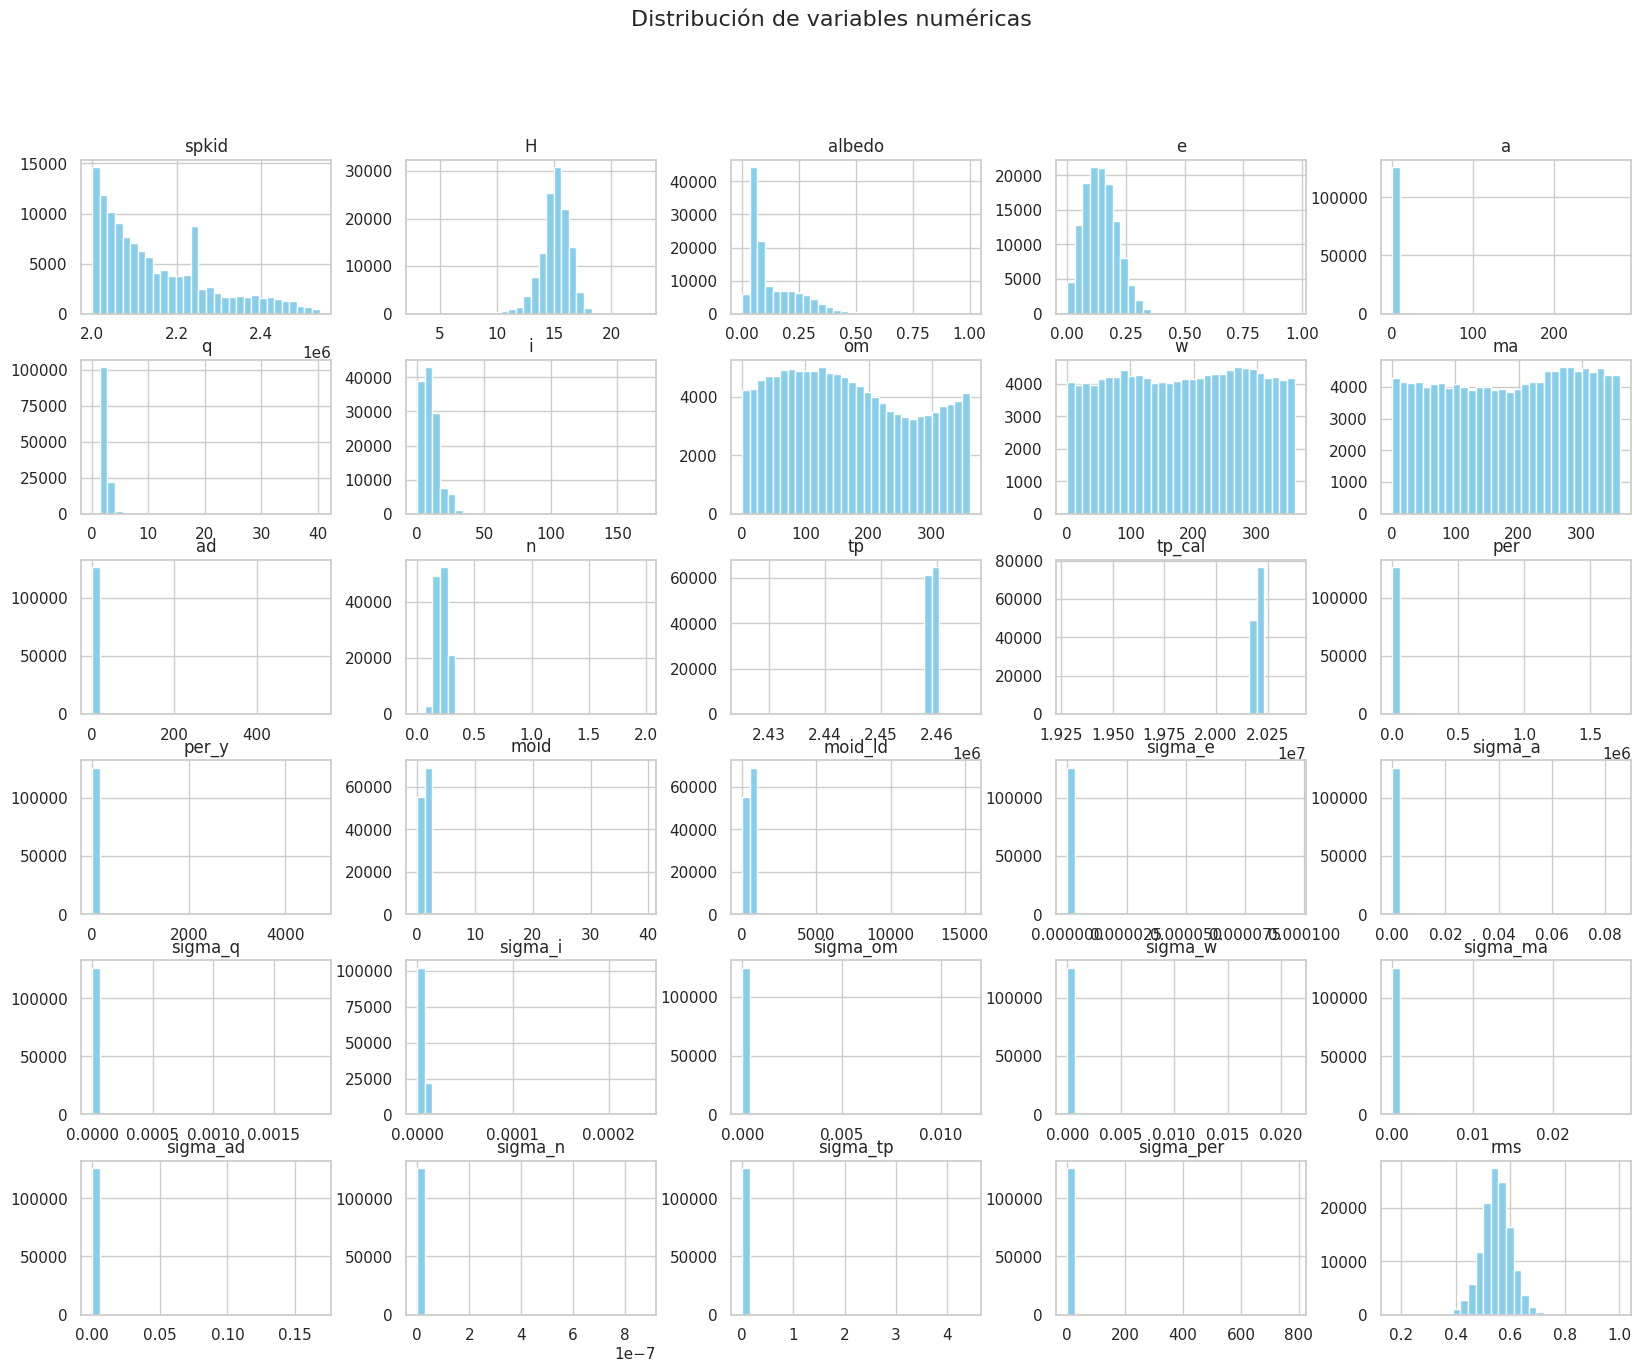

In [24]:
# Histograma general de variables numéricas
df[numeric_cols].hist(bins=30, figsize=(20, 15), color='skyblue')
plt.suptitle("Distribución de variables numéricas", fontsize=16)
plt.show()

In [25]:
# --- 4. Revisión de posibles valores no numéricos en columnas 'object' ---
object_cols = df.select_dtypes(include=['object']).columns
print("\n--- Columnas tipo object ---")
print(object_cols.tolist())

for col in object_cols:
    print(f"\nValores únicos ejemplo en {col}:")
    print(df[col].unique()[:10])


--- Columnas tipo object ---
['full_name', 'pha', 'diameter', 'diameter_sigma', 'class']

Valores únicos ejemplo en full_name:
["'     1 Ceres'" "'     2 Pallas'" "'     3 Juno'" "'     4 Vesta'"
 "'     5 Astraea'" "'     6 Hebe'" "'     7 Iris'" "'     8 Flora'"
 "'     9 Metis'" "'    10 Hygiea'"]

Valores únicos ejemplo en pha:
['N' 'Y']

Valores únicos ejemplo en diameter:
[939.4 545.0 246.596 525.4 106.699 185.18 199.83 147.491 190.0 407.12]

Valores únicos ejemplo en diameter_sigma:
['0.2' '18.0' '10.594000000000001' '3.14' '2.9' '10.0' '1.025' '?' '6.8'
 '1.008']

Valores únicos ejemplo en class:
['MBA' 'OMB' 'MCA' 'AMO' 'IMB' 'TJN' 'CEN' 'APO' 'ATE' 'AST']


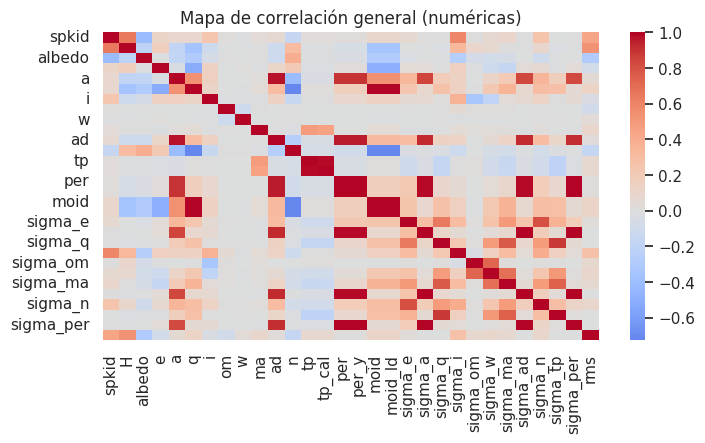

In [26]:
# --- 5. Correlación general entre variables numéricas ---
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Mapa de correlación general (numéricas)")
plt.show()

### Problema con los NaNs.
En esta parte del codigo se va aagregar un bloque de codigo
ya que en la primera revisión no se tomaron los NaN como nulos, ni otro tipo de caracter.
Esto tratando de hacer el EDA mas adelante hizo que surgiera errores a la hora de trabajar los datos para correlaciones y otro tipo de tratamientos
me apoye en una LLM para este paso


--- Tipos de datos actualizados ---
diameter          float64
diameter_sigma    float64
dtype: object

--- Cantidad de valores NaN luego de la conversión ---
diameter           3
diameter_sigma    96
dtype: int64


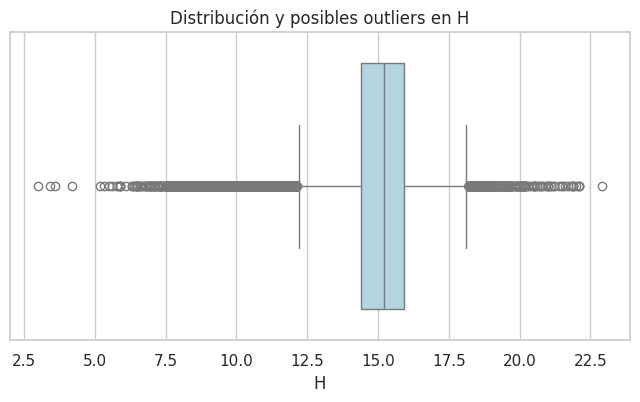

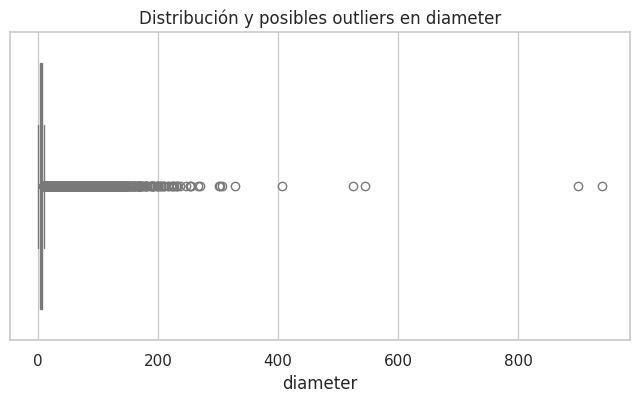

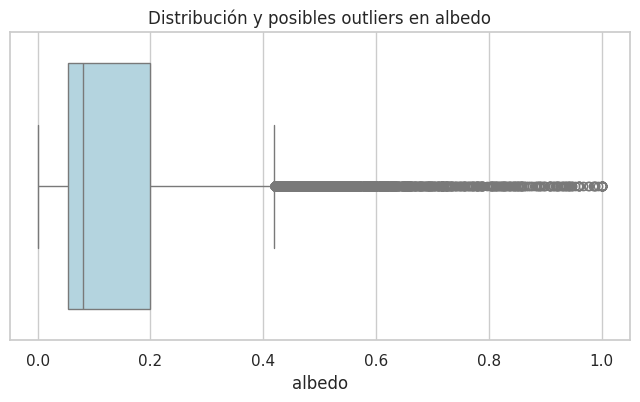

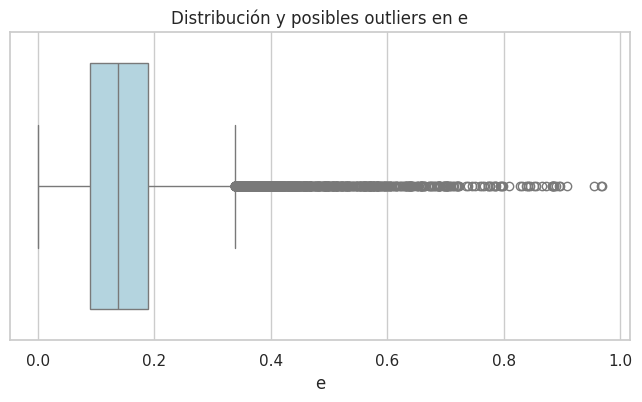

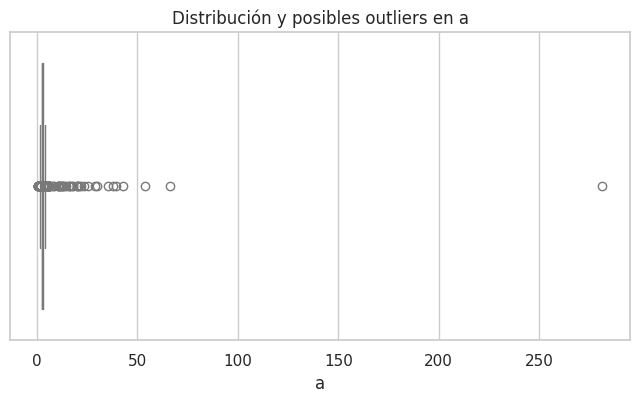

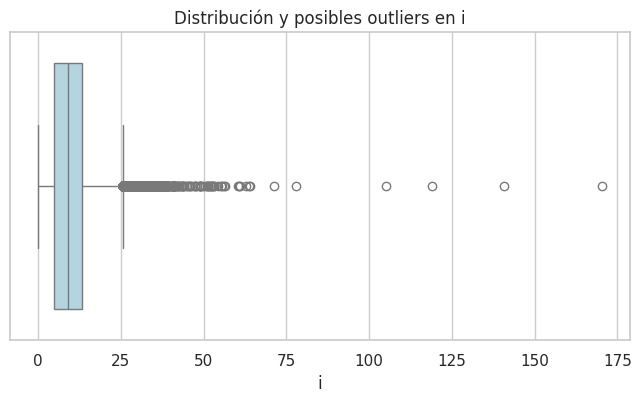

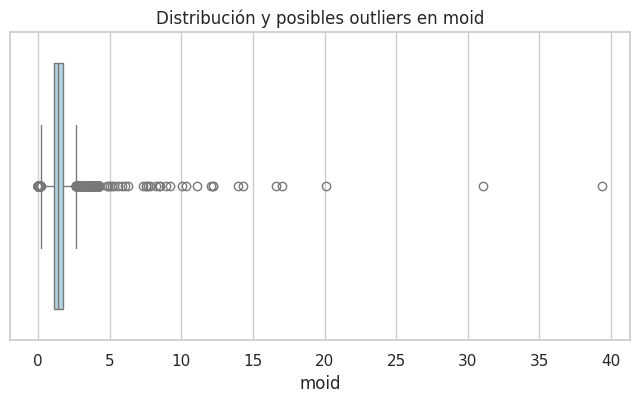

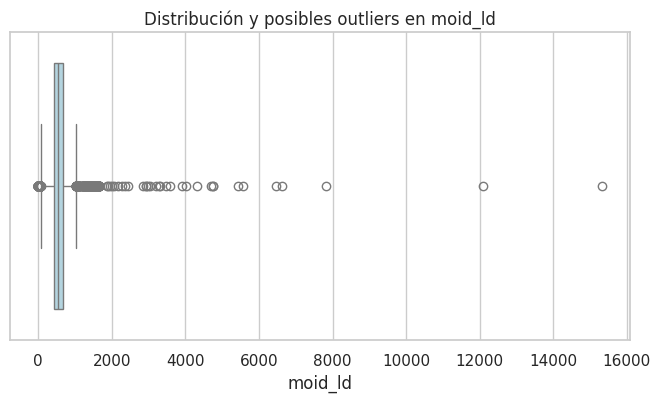

In [27]:

# Columnas con posibles errores de tipo
cols_object = ['diameter', 'diameter_sigma']

# Reemplazamos símbolos no numéricos comunes por NaN y convertimos a float
for col in cols_object:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].replace('?', np.nan), errors='coerce')

# Confirmamos los cambios
print("\n--- Tipos de datos actualizados ---")
print(df[cols_object].dtypes)

# Revisamos cuántos NaN quedaron tras la conversión
print("\n--- Cantidad de valores NaN luego de la conversión ---")
print(df[cols_object].isna().sum())

# Intentamos nuevamente el boxplot de las variables clave
key_vars = ['H', 'diameter', 'albedo', 'e', 'a', 'i', 'moid', 'moid_ld']
for var in key_vars:
    if var in df.columns:
        sns.boxplot(x=df[var], color='lightblue')
        plt.title(f"Distribución y posibles outliers en {var}")
        plt.show()


In [28]:
# Análisis analítico por clase 'pha'

# Variables numéricas relevantes
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Agrupamos por 'pha' y calculamos estadísticos descriptivos
stats_by_class = df.groupby('pha')[numeric_cols].agg(['mean', 'median', 'std', 'min', 'max'])
display(stats_by_class.T.head(30))  #  los primeros 30 para no saturar

# Medimos diferencia de medias entre clases (pha=Y vs N)
means_by_class = df.groupby('pha')[numeric_cols].mean()
means_diff = abs(means_by_class.loc['Y'] - means_by_class.loc['N'])
means_diff = means_diff.sort_values(ascending=False)

print("\n--- Variables con mayor diferencia de medias entre clases ---")
display(means_diff.head(15))

df_corr = df.copy()
df_corr['pha_bin'] = df_corr['pha'].map({'Y': 1, 'N': 0})

# Solo columnas numéricas
numeric_cols = df_corr.select_dtypes(include=['float64', 'int64']).columns
corrs = df_corr[numeric_cols].corrwith(df_corr['pha_bin']).sort_values(ascending=False)

print("\n--- Correlación con la variable objetivo (pha) ---")
display(corrs.head(15))
print("\n--- Correlaciones negativas más fuertes ---")
display(corrs.tail(15))


pha                               N             Y
spkid          mean    2.153592e+06  2.240805e+06
               median  2.114757e+06  2.242546e+06
               std     1.313257e+05  1.754323e+05
               min     2.000001e+06  2.001566e+06
               max     2.539759e+06  2.533722e+06
H              mean    1.504418e+01  1.844590e+01
               median  1.520000e+01  1.850000e+01
               std     1.327236e+00  1.793920e+00
               min     3.000000e+00  1.400000e+01
               max     2.290000e+01  2.210000e+01
diameter       mean    5.739916e+00  9.888562e-01
               median  4.150000e+00  6.630000e-01
               std     9.752366e+00  9.674051e-01
               min     9.600000e-02  8.300000e-02
               max     9.394000e+02  6.250000e+00
albedo         mean    1.348420e-01  2.032397e-01
               median  8.100000e-02  1.750000e-01
               std     1.123615e-01  1.397717e-01
               min     1.000000e-03  1.200000e-02
               max     1.000000e+00  5.780000e-01
diameter_sigma mean    4.764142e-01  1.277101e-01
               median  3.220000e-01  3.250000e-02
               std     7.865555e-01  2.585931e-01
               min     3.000000e-03  3.000000e-03
               max     1.400000e+02  2.155000e+00
e              mean    1.431680e-01  4.603379e-01
               median  1.376552e-01  4.626739e-01
               std     7.257031e-02  1.881546e-01
               min     3.094994e-04  7.395468e-02
               max     9.683957e-01  9.091728e-01


--- Variables con mayor diferencia de medias entre clases ---


,0
spkid,87212.092339
tp_cal,4761.778043
per,1047.430613
moid_ld,548.734643
tp,170.284901
w,9.157366
om,7.878533
ma,7.655426
i,5.717931
diameter,4.751060



--- Correlación con la variable objetivo (pha) ---


,0
pha_bin,1.000000
n,0.298316
e,0.151310
H,0.089673
sigma_i,0.042023
i,0.031064
spkid,0.023323
albedo,0.021383
sigma_n,0.019525
om,0.002700



--- Correlaciones negativas más fuertes ---


,0
sigma_ma,-0.003186
sigma_om,-0.006082
per_y,-0.007433
per,-0.007433
sigma_w,-0.008001
tp,-0.011577
tp_cal,-0.011593
diameter_sigma,-0.014667
diameter,-0.016965
ad,-0.019203


### Visualizaciones para el EDA con la clase 'PHA'

In [29]:
# Elegimos variables más importantes
top_diff_vars = ['spkid', 'tp_cal', 'per', 'moid_ld', 'tp', 'w', 'diameter', 'H', 'per_y', 'q']
top_corr_vars = ['n', 'e', 'H', 'sigma_i', 'i', 'spkid', 'albedo']

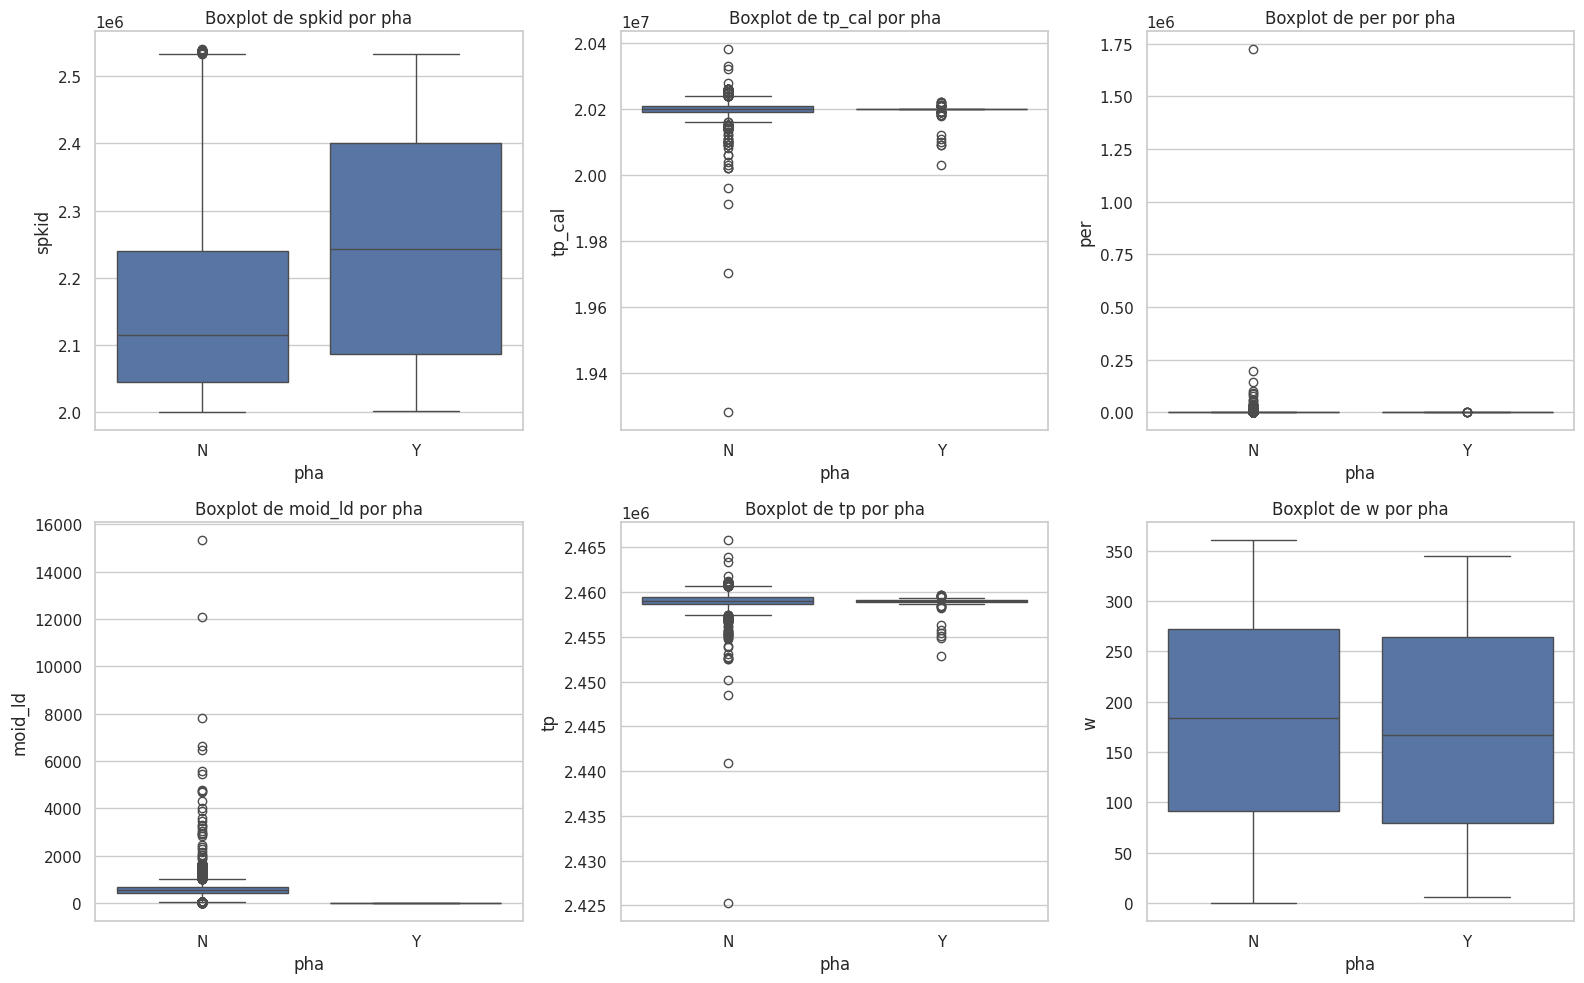

In [30]:
# --- Boxplots para variables con mayor diferencia de medias ---
plt.figure(figsize=(16, 10))
for i, col in enumerate(top_diff_vars[:6], 1):  # mostramos 6 primero para que no quede gigante
    plt.subplot(2, 3, i)
    sns.boxplot(x='pha', y=col, data=df)
    plt.title(f'Boxplot de {col} por pha')
plt.tight_layout()
plt.show()

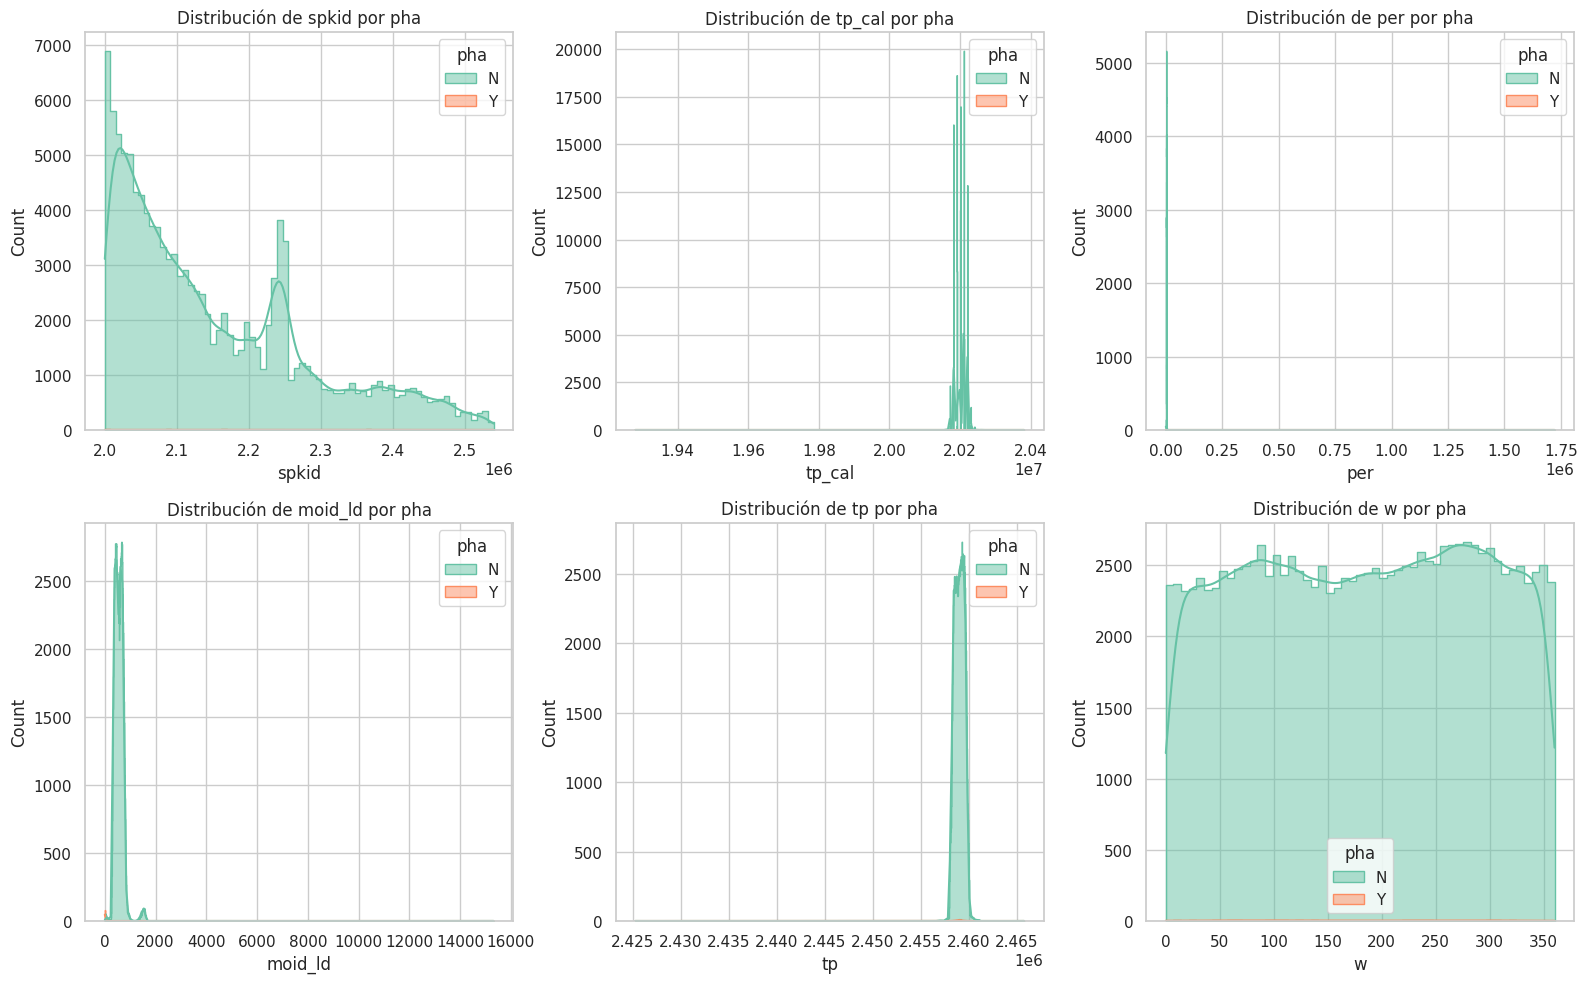

In [15]:
# --- Histogramas / KDE para ver distribuciones ---
plt.figure(figsize=(16, 10))
for i, col in enumerate(top_diff_vars[:6], 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=col, hue='pha', kde=True, element='step', palette='Set2', alpha=0.5)
    plt.title(f'Distribución de {col} por pha')
plt.tight_layout()
plt.show()

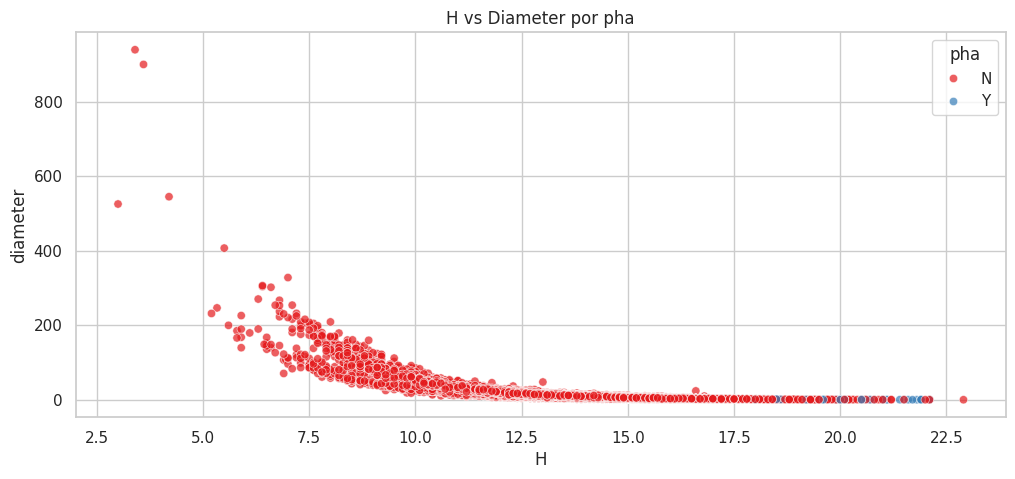

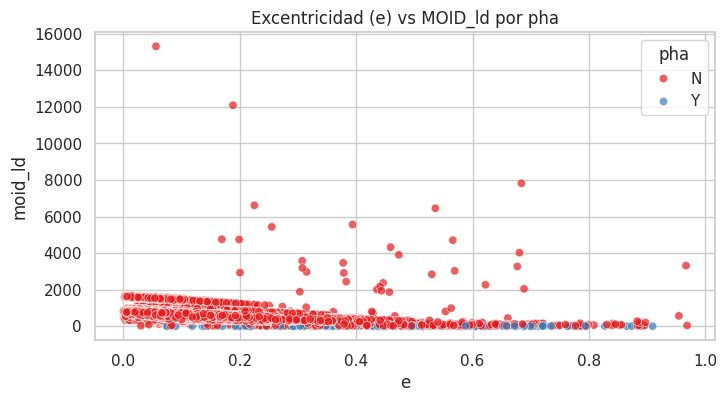

In [16]:
# --- Scatterplots 2D para combinación de variables relevantes ---
plt.figure(figsize=(12, 5))
sns.scatterplot(x='H', y='diameter', hue='pha', data=df, palette='Set1', alpha=0.7)
plt.title('H vs Diameter por pha')
plt.show()

sns.scatterplot(x='e', y='moid_ld', hue='pha', data=df, palette='Set1', alpha=0.7)
plt.title('Excentricidad (e) vs MOID_ld por pha')
plt.show()

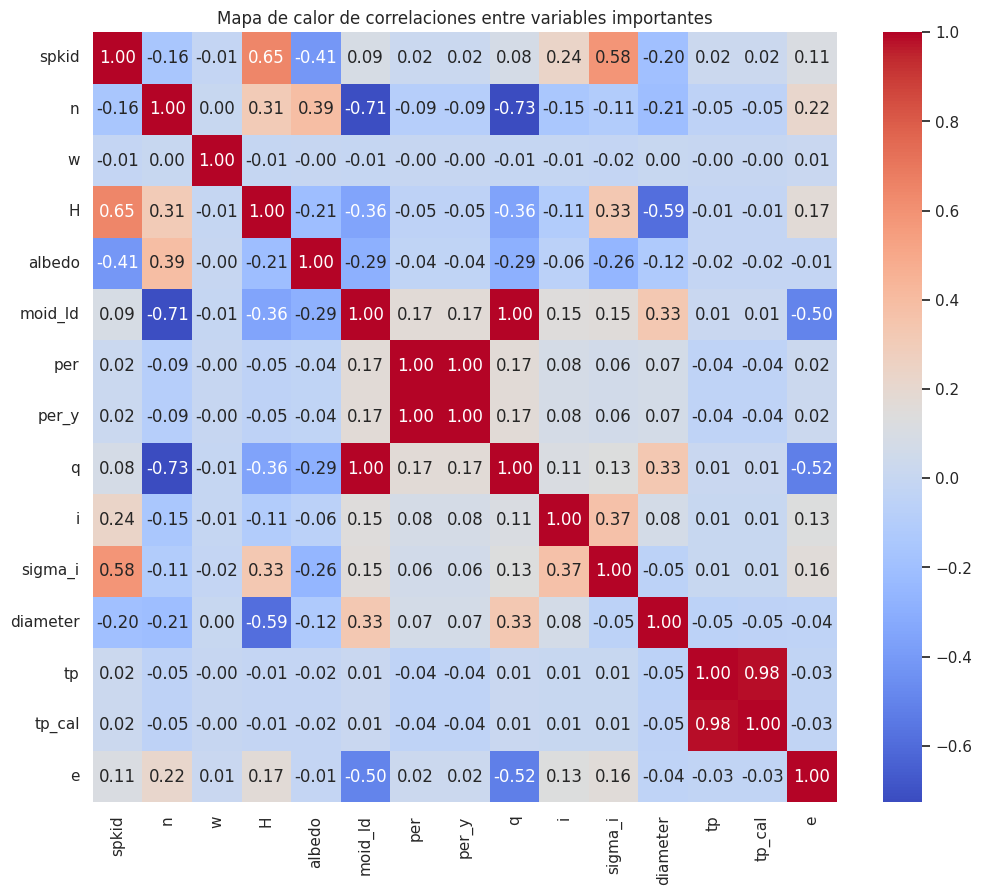

In [17]:
# --- Heatmap de correlación de variables importantes ---
important_vars = list(set(top_diff_vars + top_corr_vars))
df_corr_numeric = df[important_vars].select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(12, 10))
sns.heatmap(df_corr_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Mapa de calor de correlaciones entre variables importantes')
plt.show()

# INFORME DE ANÁLISIS EXPLORATORIO DE DATOS (EDA)
-- Carga de datos

El dataset de asteroides fue importado correctamente desde Google Drive utilizando pandas.read_csv().
Se verificó su estructura con info() y head(), confirmando que las columnas se cargaron con sus nombres y tipos adecuados.
No se detectaron duplicados ni errores de lectura.

-- Limpieza y conversión de tipos

En esta etapa se realizaron ajustes de tipado para variables numéricas como diameter y diameter_sigma, convirtiéndolas a float64.
Se comprobó la existencia de valores nulos, encontrándose 3 en diameter y 96 en diameter_sigma.
El resto de las variables no presentó ausencias significativas.

-- Análisis univariado

Se aplicaron medidas descriptivas (describe()) y visualizaciones de frecuencia e histograma.
Los resultados mostraron que:

Diámetro: la mayoría de los asteroides tienen tamaños pequeños, con una distribución sesgada hacia la izquierda.

Magnitud absoluta (H): los valores se concentran entre 20 y 25, lo que refleja objetos relativamente tenues.

pha (potencialmente peligroso): la clase "N" predomina fuertemente, indicando un desbalance de clases importante.

-- Correlación de variables

Se generó una nueva columna pha_bin (Y=1, N=0) para poder analizar la correlación numérica.
El cálculo de la matriz de correlación permitió identificar relaciones directas e inversas entre las variables.
Las más destacadas son:

Relative_velocity y miss_distance, que muestran mayor relación con pha.

Las correlaciones no son extremadamente altas, lo que sugiere que la peligrosidad no depende de una sola variable, sino de una combinación de factores.

Conclusión: el comportamiento de los asteroides peligrosos está influido por múltiples variables, especialmente aquellas relacionadas con su velocidad y distancia de aproximación.

-- Análisis bivariado y visualización

Se realizaron comparaciones mediante scatterplot, pairplot y gráficos categóricos (hue="pha").
Las visualizaciones mostraron que:

Los asteroides peligrosos tienden a tener mayor diámetro y menor distancia mínima de paso.

No se observan separaciones completamente lineales, lo que sugiere que el modelo a emplear debe manejar fronteras no lineales (como un árbol o KNN).

-- Preparación para modelado

Se eliminan columnas irrelevantes (por ejemplo, nombres o identificadores), y se codifica la variable objetivo pha a formato binario.
El dataset final queda compuesto solo por variables numéricas relevantes y sin errores de tipo.

-- Conclusión general del EDA --

El análisis exploratorio permitió entender la estructura, distribución y relaciones principales del dataset.

-- Los hallazgos más relevantes son: --

La mayoría de los asteroides no son peligrosos (clase "N").

Los asteroides peligrosos tienden a ser más grandes y a pasar más cerca de la Tierra.

La correlación entre variables es moderada, por lo que se justifica el uso de métodos multivariados de clasificación.
